<a href="https://colab.research.google.com/github/edjnolasco/transport-ml-rd/blob/main/notebooks/practica2_transporte_svm_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica 2 – Clasificación en Transporte con SVM  
## Versión de la Práctica 2 para Google Colab


**Autor:** Edwin José Nolasco  
**Caso de estudio:** Dominio transporte  

**Algoritmo principal:** Support Vector Machine (SVM) con kernel RBF
**Catedrática:** María Belén Pérez Sánchez, PhD.
**Asignatura:** INF-9005-C2 Algoritmos de Clasificación en Machine Learning.
**Universidad Autónoma de Santo Domingo - UASD**
---

## Propósito de la notebook

Esta notebook fue estructurada como una evidencia de entrega reproducible en Google Colab.  
Su objetivo es reconstruir, ejecutar y documentar el flujo de trabajo de la Práctica 2
a partir del repositorio del proyecto, manteniendo la lógica modular implementada en `src/`.

La secuencia de trabajo sigue estas fases:

1. Preparación del entorno y descarga del repositorio.
2. Carga y limpieza básica del conjunto de datos.
3. Construcción explícita de la variable objetivo binaria.
4. Identificación automática de variables numéricas y categóricas.
5. Entrenamiento del modelo SVM con el pipeline real del proyecto.
6. Evaluación cuantitativa y visual del desempeño.
7. Generación de artefactos reproducibles para la entrega.

---

## Justificación metodológica

El repositorio trabaja con un dataset crudo de transporte que contiene observaciones por provincia y año.
Como el archivo base no incorpora directamente la etiqueta binaria `target`,
en esta notebook se construye dicha variable a partir del percentil 75 de la variable de fallecidos.
Este criterio convierte el problema en una tarea de clasificación binaria de riesgo relativo,
coherente con la narrativa metodológica desarrollada en la práctica.

Desde el punto de vista del aprendizaje automático, el uso de un SVM con kernel RBF resulta pertinente
cuando la separación entre clases no es estrictamente lineal en el espacio original de variables.
La combinación de imputación, codificación one-hot y escalado permite que el clasificador opere
sobre una representación homogénea y estable para entrenamiento y evaluación.

## 1. Preparación del entorno

En esta sección se instalan dependencias mínimas, se descarga el repositorio desde GitHub
y se habilita la importación de los módulos contenidos en `src/`.

In [50]:
# Dependencias base para ejecutar la práctica en Colab.
!pip -q install pandas numpy scikit-learn matplotlib joblib

In [51]:
# Descarga del repositorio del proyecto.
!rm -rf transport-ml-rd
!git clone https://github.com/edjnolasco/transport-ml-rd.git

Cloning into 'transport-ml-rd'...
remote: Enumerating objects: 183, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (38/38), done.
Receiving objects: 100% (183/183), 109.80 KiB | 2.20 MiB/s, done.
remote: Total 183 (delta 22), reused 11 (delta 11), pack-reused 134 (from 1)
Resolving deltas: 100% (64/64), done.


In [52]:
# Configuración general del entorno.
import os
import sys
import json
from pathlib import Path
from datetime import datetime

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Para que Colab pueda importar el paquete src del repositorio.
PROJECT_ROOT = Path("/content/transport-ml-rd").resolve()
sys.path.append(str(PROJECT_ROOT))

# Importaciones exactas del código del repo.
from src.config import build_config
from src.data_processing import load_dataset, basic_cleaning, save_processed_dataset
from src.features import split_features_target, detect_feature_types
from src.modeling import build_model
from src.evaluation import (
    calculate_metrics,
    save_metrics_table,
    save_classification_report,
    save_confusion_matrix,
    save_roc_curve,
    save_runtime_summary,
)
from src.utils import ensure_project_dirs, Timer

# Semilla global para reproducibilidad.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

config = build_config(PROJECT_ROOT)

print("Proyecto:", PROJECT_ROOT)
print("Archivo de entrada esperado por config:", config.input_file)
print("Archivo procesado:", config.processed_file)
print("Modelo:", config.model_file)

Proyecto: /content/transport-ml-rd
Archivo de entrada esperado por config: /content/transport-ml-rd/data/raw/transport_data.csv
Archivo procesado: /content/transport-ml-rd/data/processed/transport_clean.csv
Modelo: /content/transport-ml-rd/models/svm_transport_model.joblib


## 2. Verificación de estructura del proyecto

Antes de ejecutar el flujo, se valida la disponibilidad de carpetas y se crean
los directorios necesarios para almacenar tablas, figuras y modelo entrenado.

In [53]:
# Creación de carpetas de salida si no existen.
ensure_project_dirs([
    config.data_processed_dir,
    config.reports_figures_dir,
    config.reports_tables_dir,
    config.models_dir,
])

for path in [
    config.data_raw_dir,
    config.data_processed_dir,
    config.reports_figures_dir,
    config.reports_tables_dir,
    config.models_dir,
]:
    print(path, "->", path.exists())

/content/transport-ml-rd/data/raw -> True
/content/transport-ml-rd/data/processed -> True
/content/transport-ml-rd/reports/figures -> True
/content/transport-ml-rd/reports/tables -> True
/content/transport-ml-rd/models -> True


## 3. Carga y limpieza básica del dataset

El proyecto implementa una limpieza inicial mediante `basic_cleaning`,
la cual normaliza nombres de columnas y elimina duplicados.
En esta notebook se respeta exactamente ese comportamiento.

In [54]:
# Carga del dataset usando la función real del proyecto.
df_raw = load_dataset(str(config.input_file))
print("Dimensión original:", df_raw.shape)
display(df_raw.head())

Dimensión original: (351, 3)


,provincia,year,fallecidos
0,Azua,2016,64
1,Bahoruco,2016,21
2,Barahona,2016,34
3,Dajabón,2016,21
4,Distrito Nacional,2016,65


In [55]:
# Limpieza básica definida en src/data_processing.py
df = basic_cleaning(df_raw)

print("Dimensión tras limpieza básica:", df.shape)
print("Columnas disponibles:", df.columns.tolist())
display(df.head())

Dimensión tras limpieza básica: (351, 3)
Columnas disponibles: ['provincia', 'year', 'fallecidos']


,provincia,year,fallecidos
0,Azua,2016,64
1,Bahoruco,2016,21
2,Barahona,2016,34
3,Dajabón,2016,21
4,Distrito Nacional,2016,65


## 4. Perfil descriptivo del conjunto de datos

Se examinan estructura, tipos de datos, valores faltantes y estadísticos básicos.
Este diagnóstico es importante porque permite justificar la construcción posterior
de la variable objetivo y la composición del pipeline de preprocesamiento.

In [56]:
# Información general del conjunto de datos.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 351 entries, 0 to 350
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   provincia   351 non-null    object
 1   year        351 non-null    int64 
 2   fallecidos  351 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 8.4+ KB


In [57]:
# Resumen descriptivo de variables numéricas.
display(df.describe(include="all").transpose())

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
provincia,351,63,Azua,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,351.0,NaN,NaN,NaN,2020.985755,3.159986,2016.0,2018.0,2021.0,2024.0,2026.0
fallecidos,351.0,NaN,NaN,NaN,54.079772,53.216157,1.0,17.5,40.0,66.5,299.0


In [58]:
# Conteo de valores faltantes por columna.
missing_summary = df.isna().sum().sort_values(ascending=False).to_frame("missing_values")
display(missing_summary)

,missing_values
provincia,0
year,0
fallecidos,0


## 5. Construcción de la variable objetivo

El archivo crudo contiene la variable `fallecidos`, pero no la etiqueta binaria `target`.
Por tanto, la etiqueta se deriva aquí usando el percentil 75 como punto de corte.

### Regla de transformación

- `target = 1` si `fallecidos >= percentil_75`
- `target = 0` en caso contrario

Esta formulación define como casos de mayor riesgo a las observaciones con niveles
relativamente altos de fallecidos dentro del conjunto analizado.

In [59]:
# Construcción de la variable objetivo binaria.
threshold = df["fallecidos"].quantile(0.75)
df[config.target_column] = (df["fallecidos"] >= threshold).astype(int)

print(f"Umbral (percentil 75 de 'fallecidos'): {threshold:.4f}")
print("\nDistribución de clases:")
display(df[config.target_column].value_counts().rename_axis("target").to_frame("count"))

Umbral (percentil 75 de 'fallecidos'): 66.5000

Distribución de clases:


,count
target,
0,263
1,88


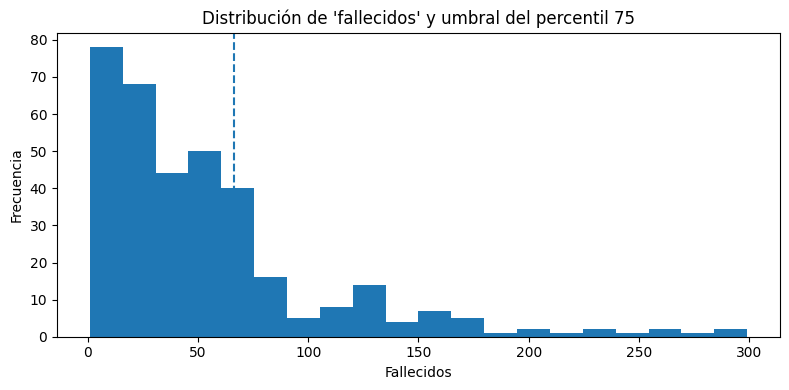

In [60]:
# Visualización simple de la distribución de la variable de interés.
plt.figure(figsize=(8, 4))
plt.hist(df["fallecidos"], bins=20)
plt.axvline(threshold, linestyle="--")
plt.title("Distribución de 'fallecidos' y umbral del percentil 75")
plt.xlabel("Fallecidos")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

## 6. Persistencia del dataset procesado

Una vez construida la variable objetivo, se guarda una versión procesada del dataset.
Este paso mejora la trazabilidad del experimento y permite reutilización posterior.

In [61]:
save_processed_dataset(df, str(config.processed_file))
print("Dataset procesado guardado en:", config.processed_file)

Dataset procesado guardado en: /content/transport-ml-rd/data/processed/transport_clean.csv


## 7. Separación entre variables predictoras y variable objetivo

A partir del dataset ya transformado, se usa la función `split_features_target`
del proyecto para obtener la matriz de entrada `X` y el vector `y`.
Luego, `detect_feature_types` identifica automáticamente las columnas numéricas
y categóricas que serán tratadas por el `ColumnTransformer`.

In [62]:
X, y = split_features_target(df, config.target_column)
numeric_features, categorical_features = detect_feature_types(X)

print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)
print("\nVariables numéricas:", numeric_features)
print("\nVariables categóricas:", categorical_features)

Dimensión de X: (351, 3)
Dimensión de y: (351,)

Variables numéricas: ['year', 'fallecidos']

Variables categóricas: ['provincia']


## 8. División entrenamiento/prueba

Se realiza una partición estratificada para preservar la distribución de clases
en los subconjuntos de entrenamiento y prueba.

In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=config.test_size,
    random_state=config.random_state,
    stratify=y,
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train distribución:")
print(y_train.value_counts(normalize=True).sort_index())
print("y_test distribución:")
print(y_test.value_counts(normalize=True).sort_index())

X_train: (280, 3)
X_test : (71, 3)
y_train distribución:
target
0    0.75
1    0.25
Name: proportion, dtype: float64
y_test distribución:
target
0    0.746479
1    0.253521
Name: proportion, dtype: float64


## 9. Construcción del pipeline real del modelo

En esta práctica no se reconstruye manualmente un modelo alternativo.
En su lugar, se utiliza directamente `build_model` del repositorio, el cual integra:

- imputación mediana para variables numéricas,
- escalado estándar,
- imputación por moda para variables categóricas,
- one-hot encoding para categorías,
- clasificador `SVC` con `kernel='rbf'`, `C=3.0` y `gamma='scale'`.

Esto garantiza coherencia con el diseño real del proyecto.

In [64]:
model = build_model(
    x=X_train,
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    kernel=config.kernel,
    c_value=config.c_value,
    gamma=config.gamma,
)

print(model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['year', 'fallecidos']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['provinc

## 10. Entrenamiento del modelo y medición de tiempo

Se entrena el pipeline completo y se registran tiempos de entrenamiento e inferencia
para dejar evidencia del costo computacional básico del experimento.

In [65]:
with Timer() as train_timer:
    model.fit(X_train, y_train)

with Timer() as inference_timer:
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

runtime_summary = {
    "train_seconds": train_timer.elapsed,
    "inference_seconds": inference_timer.elapsed,
    "timestamp_utc": datetime.utcnow().isoformat() + "Z",
    "random_state": config.random_state,
    "kernel": config.kernel,
    "c_value": config.c_value,
    "gamma": config.gamma,
    "test_size": config.test_size,
}

print("Tiempo de entrenamiento (s):", round(train_timer.elapsed, 6))
print("Tiempo de inferencia (s):", round(inference_timer.elapsed, 6))

Tiempo de entrenamiento (s): 0.031146
Tiempo de inferencia (s): 0.023263


/tmp/ipykernel_1047/3551800021.py:11: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp_utc": datetime.utcnow().isoformat() + "Z",


## 11. Evaluación cuantitativa del desempeño

A continuación se calculan métricas estándar de clasificación:
accuracy, precision, recall, F1 y AUC.
También se presenta el reporte de clasificación para la partición de prueba.

In [66]:
from sklearn.metrics import classification_report

metrics = calculate_metrics(y_test, y_pred, y_proba)
metrics_df = pd.DataFrame([metrics])

display(metrics_df)

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, zero_division=0))

,accuracy,precision,recall,f1,auc
0,0.957746,0.941176,0.888889,0.914286,0.997904



Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97        53
           1       0.94      0.89      0.91        18

    accuracy                           0.96        71
   macro avg       0.95      0.94      0.94        71
weighted avg       0.96      0.96      0.96        71



## 12. Análisis visual: matriz de confusión y curva ROC

Estas visualizaciones permiten examinar de forma complementaria la capacidad discriminativa del modelo.

In [67]:
# Guardado de artefactos exactamente con las funciones del repo.
metrics_path = config.reports_tables_dir / "metrics_test.csv"
classification_report_path = config.reports_tables_dir / "classification_report_test.csv"
conf_matrix_path = config.reports_figures_dir / "confusion_matrix_test.png"
roc_curve_path = config.reports_figures_dir / "roc_curve_test.png"
runtime_path = config.reports_tables_dir / "runtime_summary.json"

save_metrics_table(metrics, metrics_path)
save_classification_report(y_test, y_pred, classification_report_path)
save_confusion_matrix(y_test, y_pred, conf_matrix_path)
save_roc_curve(y_test, y_proba, roc_curve_path)
save_runtime_summary(runtime_summary, runtime_path)

print("Artefactos guardados.")
print(metrics_path)
print(classification_report_path)
print(conf_matrix_path)
print(roc_curve_path)
print(runtime_path)

Artefactos guardados.
/content/transport-ml-rd/reports/tables/metrics_test.csv
/content/transport-ml-rd/reports/tables/classification_report_test.csv
/content/transport-ml-rd/reports/figures/confusion_matrix_test.png
/content/transport-ml-rd/reports/figures/roc_curve_test.png
/content/transport-ml-rd/reports/tables/runtime_summary.json


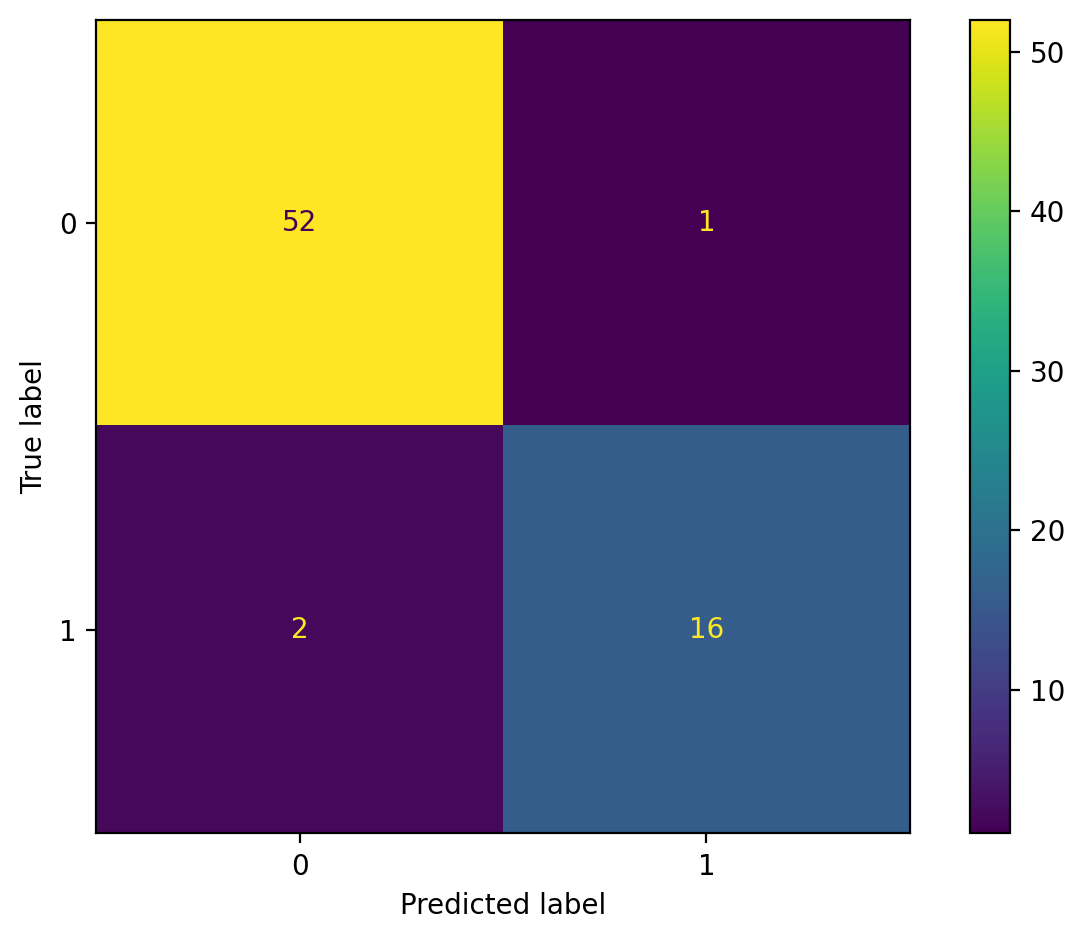

In [68]:
# Visualización en notebook de la matriz de confusión guardada.
from IPython.display import Image, display

display(Image(filename=str(conf_matrix_path)))

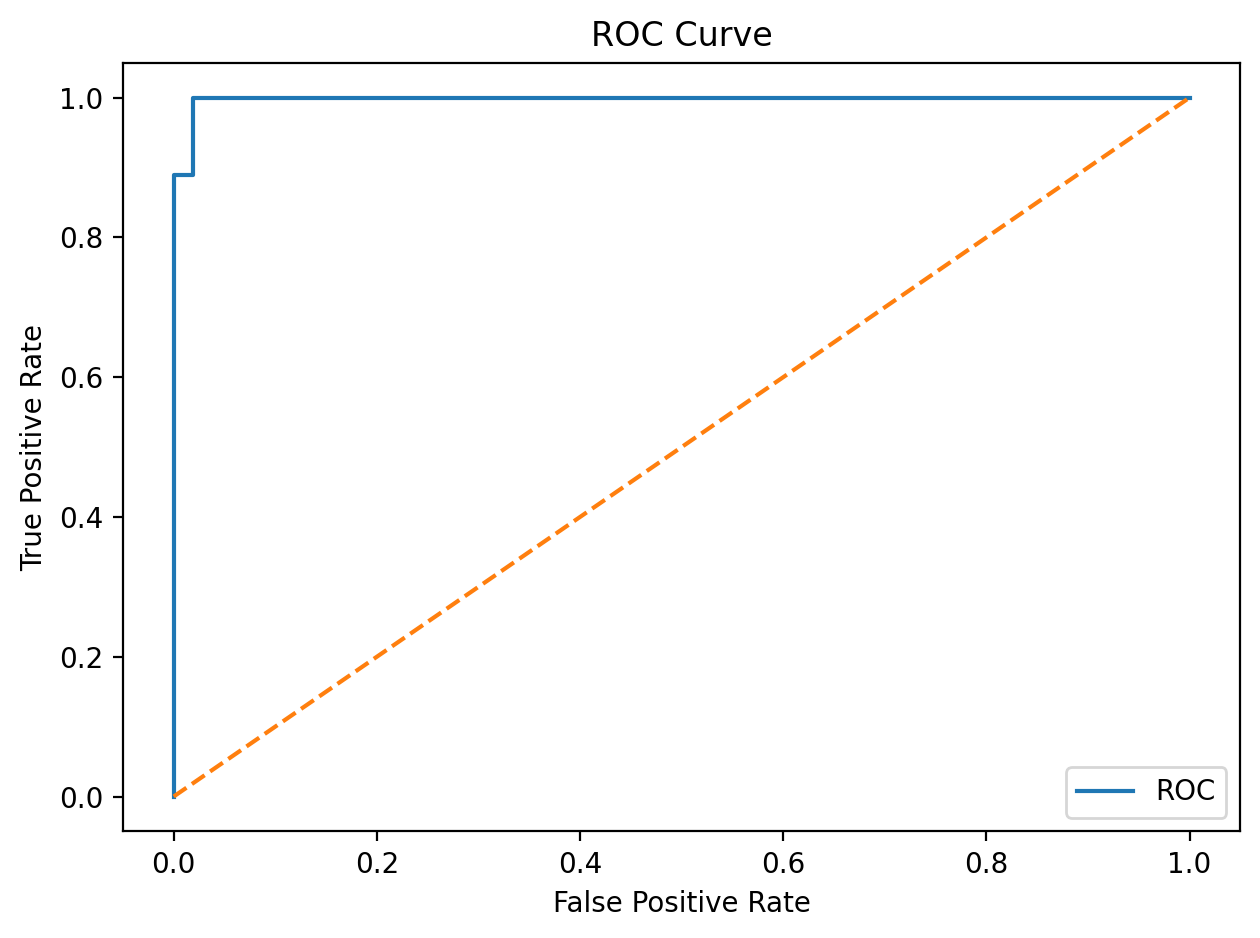

In [69]:
# Visualización en notebook de la curva ROC guardada.
display(Image(filename=str(roc_curve_path)))

## 13. Guardado del modelo entrenado

El pipeline completo se serializa con `joblib`.
Esto permite reutilizar tanto el preprocesamiento como el clasificador final
sin rehacer manualmente cada etapa.

In [70]:
joblib.dump(model, config.model_file)
print("Modelo guardado en:", config.model_file)

Modelo guardado en: /content/transport-ml-rd/models/svm_transport_model.joblib


## 14. Revisión de salidas generadas

Se listan los principales archivos producidos por la ejecución de la práctica.

In [71]:
artifacts = [
    config.processed_file,
    metrics_path,
    classification_report_path,
    conf_matrix_path,
    roc_curve_path,
    runtime_path,
    config.model_file,
]

artifact_df = pd.DataFrame({
    "artifact": [str(p) for p in artifacts],
    "exists": [Path(p).exists() for p in artifacts],
    "size_bytes": [Path(p).stat().st_size if Path(p).exists() else None for p in artifacts],
})

display(artifact_df)

,artifact,exists,size_bytes
0,/content/transport-ml-rd/data/processed/transp...,True,7944
1,/content/transport-ml-rd/reports/tables/metric...,True,128
2,/content/transport-ml-rd/reports/tables/classi...,True,395
3,/content/transport-ml-rd/reports/figures/confu...,True,27146
4,/content/transport-ml-rd/reports/figures/roc_c...,True,53998
5,/content/transport-ml-rd/reports/tables/runtim...,True,237
6,/content/transport-ml-rd/models/svm_transport_...,True,10230


## 15. Compresión de resultados para entrega

Se crea un archivo `.zip` con los artefactos más relevantes del experimento.

In [72]:
import zipfile

zip_path = PROJECT_ROOT / "reports" / "practica2_artifacts_colab.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for artifact in artifacts:
        artifact = Path(artifact)
        if artifact.exists():
            zf.write(artifact, artifact.relative_to(PROJECT_ROOT))

print("ZIP generado en:", zip_path)

ZIP generado en: /content/transport-ml-rd/reports/practica2_artifacts_colab.zip


## 16. Discusión técnica

Los resultados deben interpretarse dentro de un marco metodológico acotado.

### 16.1 Sobre la construcción del problema
El dataset original no ofrece una clase binaria ya definida. Por ello, la formulación del problema de clasificación
depende de una decisión de modelado: transformar `fallecidos` en una etiqueta binaria según el percentil 75.
Esto convierte el ejercicio en una clasificación relativa de riesgo, no en una predicción causal del fenómeno.

### 16.2 Sobre el comportamiento del SVM
El uso del kernel RBF permite modelar fronteras de decisión no lineales, lo cual resulta conveniente
cuando las variables observadas no separan naturalmente las clases en el espacio original.
La combinación de escalado y codificación categórica es esencial para que el SVM opere en condiciones adecuadas.

### 16.3 Sobre la interpretabilidad
Aunque el modelo puede ofrecer un buen desempeño predictivo, su interpretabilidad directa es limitada.
Esto implica que los resultados son más útiles para discriminación y priorización que para explicar
de forma transparente la contribución puntual de cada predictor.

### 16.4 Sobre la validez del experimento
El valor de las métricas depende del tamaño del dataset, de la estrategia de binarización y de la partición entrenamiento/prueba.
Por tanto, las conclusiones deben entenderse como válidas para este entorno académico específico
y no como una generalización automática a otros escenarios del transporte.

## 17. Conclusiones

A partir del repositorio del proyecto, fue posible reconstruir un flujo reproducible de clasificación
en Google Colab respetando la arquitectura modular implementada en `src/`.

La práctica confirma que:

1. el problema puede formularse como una clasificación binaria de riesgo relativo mediante una regla explícita de binarización;
2. el pipeline de preprocesamiento y modelado del proyecto es consistente con buenas prácticas de machine learning tabular;
3. el SVM con kernel RBF constituye una alternativa sólida para este tipo de tarea cuando la separación entre clases no es puramente lineal;
4. la evidencia de salida puede organizarse de forma reproducible mediante tablas, figuras, archivo serializado del modelo y resumen de tiempos.

En síntesis, esta notebook no sustituye el repositorio, sino que lo operacionaliza en un formato de entrega académico,
ejecutable y verificable dentro del entorno Colab.

## 18. Trabajo futuro

Como continuidad natural hacia una práctica posterior, se recomienda:

- explorar sensibilidad del modelo respecto a `C` y `gamma`;
- comparar distintos kernels;
- incorporar validación cruzada;
- evaluar reducción de variables y estrategias de Green AI;
- estudiar estabilidad temporal del modelo cuando se entrena con distintos cortes de años.